# Generating Realistic Archipelagos with Perlin Noise

Inspired by this article: [Playing with Perlin Noise: Generating Realistic Archipelagos](https://medium.com/@yvanscher/playing-with-perlin-noise-generating-realistic-archipelagos-b59f004d8401)


In [1]:
import functools
import itertools
import math

import noise
import numpy as np
import matplotlib.pyplot as plt


## Generate the Perlin Noise

In [2]:
def generate_world(width, height, scale=100.0, **kwargs):
    """Generate a 2D world using Perlin noise.

    Parameters:
        width (int): The width of the world.
        height (int): The height of the world.
        scale (float): The scale of the noise.
        **kwargs: Additional keyword arguments for the noise function.

    Returns:
        np.ndarray: A 2D array representing the generated world.

    """

    world = np.zeros((width, height))

    for x in range(width):
        for y in range(height):
            world[x][y] = noise.pnoise2(
                x / scale, y / scale,
                repeatx=width,
                repeaty=height,
                **kwargs
            )

    return world

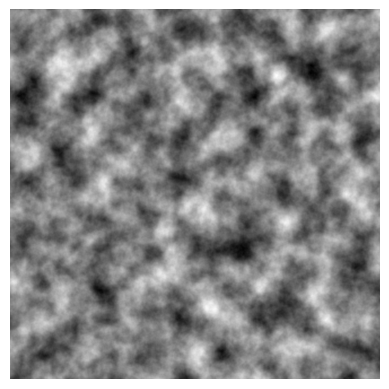

In [3]:
width = 1024
height = 1024
scale = 100.0
octaves = 6
persistence = 0.5
lacunarity = 2.0

world = generate_world(width, height, scale, octaves=octaves, persistence=persistence, lacunarity=lacunarity)

plt.imshow(world, cmap='gray')
plt.axis('off')
plt.show()

In [4]:
world.min(), world.max()

(np.float64(-0.4594406187534332), np.float64(0.4691755771636963))

## Add Colors

In [5]:
BLUE = (65, 105, 225)
GREEN = (34, 139, 34)
DARK_GREEN = (0, 100, 0)
YELLOW = (238, 214, 175)
WHITE = (250, 250, 250)
GRAY = (139, 137, 137)


def get_basic_color(point, threshold=0):
    """
    Get a basic color based on the point value and threshold.

    Parameters:
        point (float): The value of the point.
        threshold (float): The threshold value to determine the color.

    Returns:
        tuple: The RGB color corresponding to the point value.

    """

    if point < threshold - 0.05:
        return BLUE
    elif point < threshold:
        return YELLOW
    else:
        return GREEN


def get_color(point, threshold=0):
    """
    Get a color based on the point value and threshold with more detailed gradation.

    Parameters:
        point (float): The value of the point.
        threshold (float): The threshold value to determine the color.

    Returns:
        tuple: The RGB color corresponding to the point value.

    """

    if point < threshold + 0.05:
        return BLUE
    elif point < threshold + 0.1:
        return YELLOW
    elif point < threshold + 0.25:
        return GREEN
    elif point < threshold + 0.6:
        return DARK_GREEN
    elif point < threshold + 0.7:
        return GRAY
    elif point < threshold + 1.0:
        return WHITE

    return WHITE

def add_color_to_world(world, get_color=get_basic_color):
    """Add color to the world based on the provided color function.

    Parameters:
        world (np.ndarray): The 2D array representing the world.
        get_color (function): The function to get the color based on the point value.

    Returns:
        np.ndarray: A 3D array representing the colored world.

    """

    color_world = np.zeros(world.shape+(3,), dtype=np.uint8)

    for i in range(world.shape[0]):
        for j in range(world.shape[1]):
            color_world[i][j] = get_color(world[i][j])

    return color_world

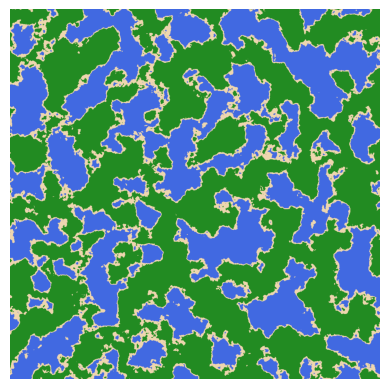

In [6]:
width = 1024
height = 1024
scale = 100.0
octaves = 6
persistence = 0.5
lacunarity = 2.0

world = generate_world(width, height, scale=scale, octaves=octaves, persistence=persistence, lacunarity=lacunarity)
color_world = add_color_to_world(world, get_color=get_basic_color)

plt.axis("off")
plt.imshow(color_world)
plt.show()

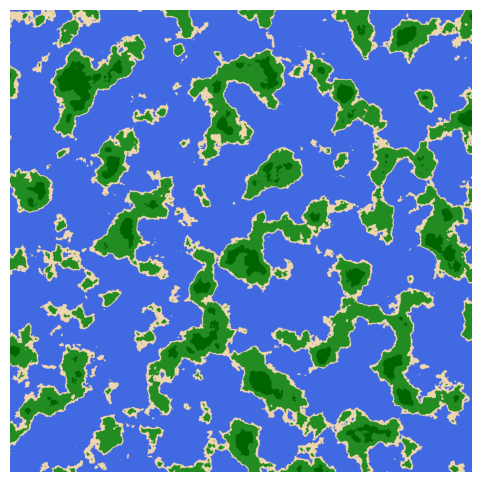

In [7]:
width = 1024
height = 1024
scale = 100.0
octaves = 6
persistence = 0.5
lacunarity = 2.0

world = generate_world(width, height, scale=scale, octaves=octaves, persistence=persistence, lacunarity=lacunarity)
color_world = add_color_to_world(world, get_color=get_color)

fig, ax = plt.subplots(figsize=(10, 6))

ax.axis("off")
ax.imshow(color_world)
fig.savefig("../images/world.png", bbox_inches="tight", pad_inches=0, dpi=300)
plt.show()

## Create a Mask

In [8]:
def mask_world(width, height, color_world):
    """Mask the world to create an island-like shape.

    Parameters:
        width (int): The width of the world.
        height (int): The height of the world.
        color_world (np.ndarray): The 3D array representing the colored world.

    Returns:
        np.ndarray: A 3D array representing the masked world with an island-like shape.

    """

    a, b = width / 2, height / 2
    n = 1024
    r = 125
    y, x = np.ogrid[-a:n-a, -b:n-b]

    # creates a mask with True False values at indices
    mask = x**2 + y**2 <= r**2

    black = [0, 0, 0]
    island_world = np.zeros_like(color_world)

    for i in range(width):
        for j in range(height):
            if mask[i][j]:
                island_world[i][j] = color_world[i][j]
            else:
                island_world[i][j] = black

    return island_world

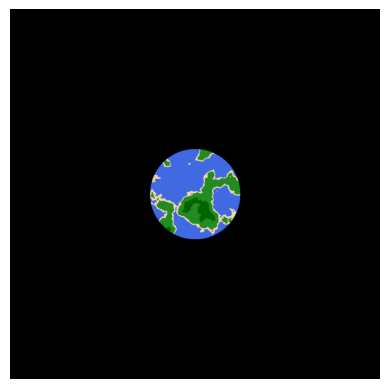

In [9]:
width = 1024
height = 1024
scale = 100.0
octaves = 6
persistence = 0.5
lacunarity = 2.0

world = generate_world(width, height, scale=scale, octaves=octaves, persistence=persistence, lacunarity=lacunarity)
color_world = add_color_to_world(world, get_color=get_color)
masked_world = mask_world(width, height, color_world)

plt.axis("off")
plt.imshow(masked_world)
plt.show()

## Use a Gradient as a Mask 

In [10]:
def get_circular_gradient(width, height):
    """Generate a circular gradient for masking.

    Parameters:
        width (int): The width of the gradient.
        height (int): The height of the gradient.

    Returns:
        np.ndarray: A 2D array representing the circular gradient.

    """

    center_x, center_y = height // 2, width // 2
    circle_grad = np.zeros_like(world)

    for y in range(world.shape[0]):
        for x in range(world.shape[1]):
            distx = abs(x - center_x)
            disty = abs(y - center_y)
            dist = math.sqrt(distx * distx + disty * disty)
            circle_grad[y][x] = dist

    # get it between -1 and 1
    max_grad = np.max(circle_grad)
    circle_grad = circle_grad / max_grad
    circle_grad -= 0.5
    circle_grad *= 2.0
    circle_grad = -circle_grad

    # shrink gradient
    for y in range(world.shape[0]):
        for x in range(world.shape[1]):
            if circle_grad[y][x] > 0:
                circle_grad[y][x] *= 20

    # get it between 0 and 1
    max_grad = np.max(circle_grad)
    circle_grad = circle_grad / max_grad

    return circle_grad

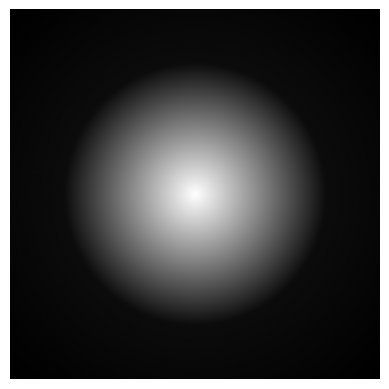

In [11]:
circle_grad = get_circular_gradient(width, height)

plt.imshow(circle_grad, cmap='gray')
plt.axis('off')
plt.show()

In [12]:
def mask_world_with_gradient(width, height, world):
    """Mask the world using a circular gradient to create an island-like shape.

    Parameters:
        width (int): The width of the world.
        height (int): The height of the world.
        world (np.ndarray): The 2D array representing the world.

    Returns:
        np.ndarray: A 2D array representing the masked world with an island-like shape.

    """

    circle_grad = get_circular_gradient(width, height)

    masked_world = np.zeros_like(world)

    for i in range(width):
        for j in range(height):
            masked_world[i][j] = world[i][j] * circle_grad[i][j]
            if masked_world[i][j] > 0:
                masked_world[i][j] *= 20

    # get it between 0 and 1
    max_grad = np.max(masked_world)
    masked_world = masked_world / max_grad

    return masked_world

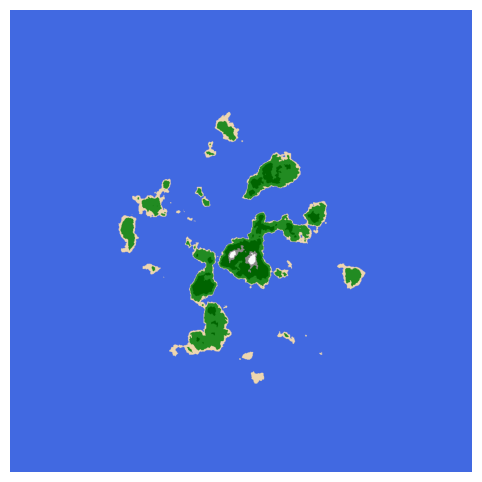

In [13]:
width = 1024
height = 1024
scale = 100.0
octaves = 6
persistence = 0.5
lacunarity = 2.0

world = generate_world(width, height, scale=scale, octaves=octaves, persistence=persistence, lacunarity=lacunarity)
masked_world = mask_world_with_gradient(width, height, world)
color_world = add_color_to_world(masked_world, get_color=functools.partial(get_color, threshold=0.1))

fig, ax = plt.subplots(figsize=(10, 6))

ax.axis("off")
ax.imshow(color_world)
fig.savefig("../images/island.png", dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()

## Scanning parameters

In [14]:
def generate_perlin_art_param(
        seed=0, lacunarity_min=1.5, lacunarity_max=3.5, persistence_min=0.1, persistence_max=1.1,
        base_min=1, base_max=99, octaves=8, width=1000, height=1000, scale=100.0):
    """Generate parameters for Perlin noise-based generative art.

    Parameters:
        seed (int): Seed for the random number generator. Default is 0.
        lacunarity_min (float): Lower limit for lacunarity. Default is 1.5.
        lacunarity_max (float): Upper limit for lacunarity. Default is 3.5.
        persistence_min (float): Lower limit for persistence. Default is 0.1.
        persistence_max (float): Upper limit for persistence. Default is 1.1.
        base_min (int): Lower limit for base value. Default is 1.
        base_max (int): Upper limit for base value. Default is 99.
        octaves (int): Number of octaves for noise generation. Default is 8.
        width (int): Width of the generated art. Default is 1000.
        height (int): Height of the generated art. Default is 1000.
        scale (float): Scale of the noise. Default is 1.

    Returns:
        dict: A dictionary containing the generated parameters for Perlin noise.

    """

    # Dictionary for storing parameters
    param = {}

    # Set seed
    np.random.seed(seed)

    # Select lacunarity and persistence from uniform distributions with specified bounds
    # Round to two decimal places so easier to print and since small changes do not greatly
    # impact the results for these parameters
    # (rounding may not be appropriate for other parameters)
    param["lacunarity"] = round(np.random.uniform(low=lacunarity_min, high=lacunarity_max),2)
    param["persistence"] = round(np.random.uniform(low=persistence_min, high=persistence_max),2)

    # Randomly generate an integer for the base value
    param["base"] = np.random.randint(low=base_min, high=base_max)

    # Add fixed parameters to dictionary
    param["octaves"] = octaves
    param["width"] = width
    param["height"] = height

    param["scale"] = scale

    return param

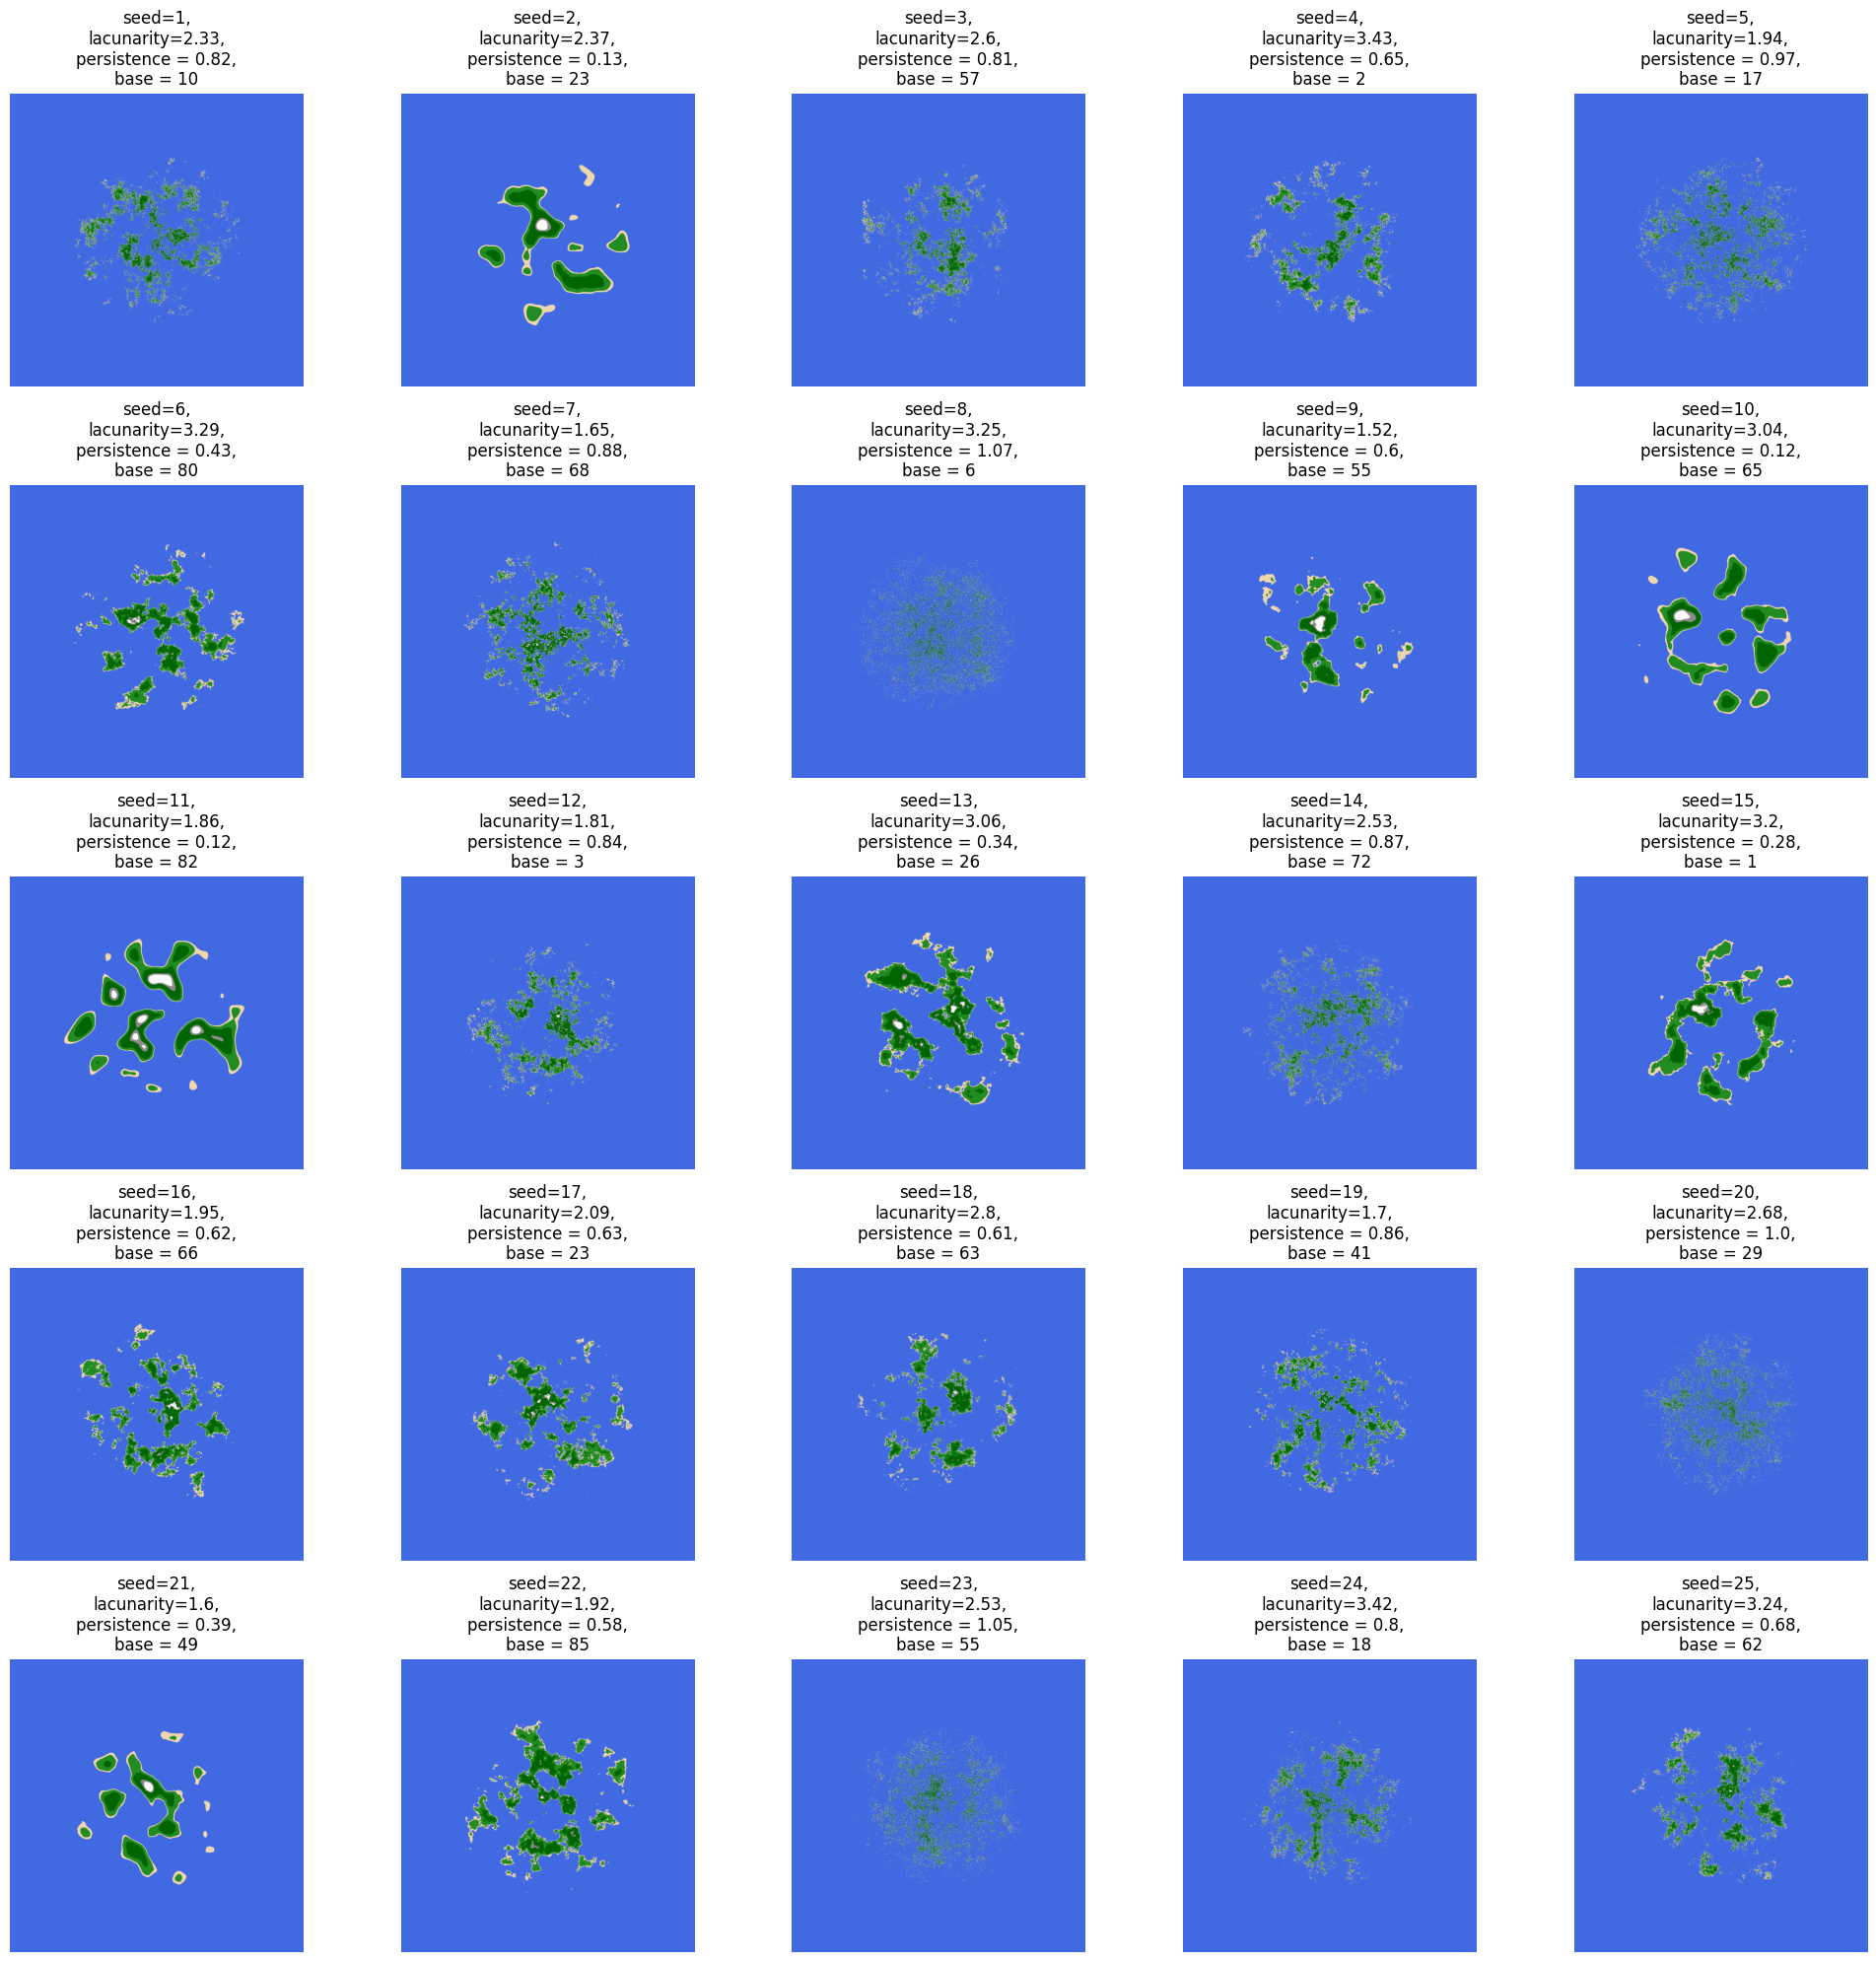

In [15]:
# Number of plots to produce
n_outputs = 25

# Variable for shifting seed values
starting_seed = 1

fig, axes = plt.subplots(5, 5, figsize=(20, 20))
axes = list(itertools.chain(*axes))

for i in range(n_outputs):
    ax = axes[i]
    seed_i = i + starting_seed
    params = generate_perlin_art_param(seed=seed_i)

    world = generate_world(**params)
    masked_world = mask_world_with_gradient(params["width"], params["height"], world)
    color_world = add_color_to_world(masked_world, get_color=functools.partial(get_color, threshold=0.1))

    ax = axes[i]
    ax.axis("off")
    ax.imshow(color_world)
    ax.set_title(
        f"seed={seed_i},\n"
        f"lacunarity={params['lacunarity']},\n"
        f"persistence = {params['persistence']},\n"
        f"base = {params['base']}"
    )

fig.tight_layout()
plt.show()